# Exploratory Data Analysis — Insurance Premium Prediction

**Objective**: Understand the relationships between customer attributes (age, BMI, smoking status, etc.) 
and medical insurance charges to inform feature engineering and model selection decisions.

**Dataset**: Medical Cost Personal Dataset (1,338 records, 7 features)

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Setup & Imports

Loading required libraries for data manipulation, numerical operations, and visualization. 
`pandas` and `numpy` handle data processing, while `matplotlib` and `seaborn` are used for creating visualizations throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns',None)
sns.set_style('whitegrid')

## 2. Load Dataset

Loading the raw insurance dataset and performing an initial inspection of its shape and structure.

In [2]:
df = pd.read_csv('../data/raw/insurance.csv')

In [25]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Data Types & Structure Check

Verifying data types for each column and confirming there are no unexpected type mismatches 
(e.g., numeric columns stored as text). This is a critical first check before any feature engineering.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


## 4. Statistical Summary

Generating descriptive statistics (mean, std, min, max, percentiles) for all numeric columns 
to understand the distribution and identify potential outliers or anomalies early on.

In [27]:
#Statistical summary
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 5. Missing Value Check

Explicitly checking for missing/null values across all columns. 
Result: dataset is complete with zero missing values, so no imputation strategy is required.

In [28]:
#Check for misisng values explicitly
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 6. Target Variable Distribution — Charges

Visualizing the distribution of `charges` (our target variable) to understand its shape.

**Finding**: The distribution is right-skewed (mean $13,270 > median $9,382), 
meaning most individuals have lower medical costs, while a smaller group has significantly 
higher costs — likely driven by factors like smoking status. This skewness will be considered 
during model selection and may require a log transformation later.

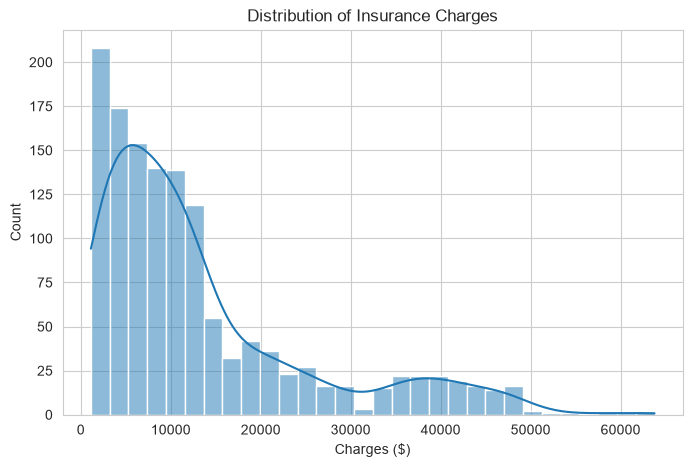

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.ylabel('Count')
plt.show()

## 7. Charges by Smoking Status

Comparing the distribution of `charges` between smokers and non-smokers using a boxplot, 
to test the hypothesis that smoking significantly increases medical insurance costs.

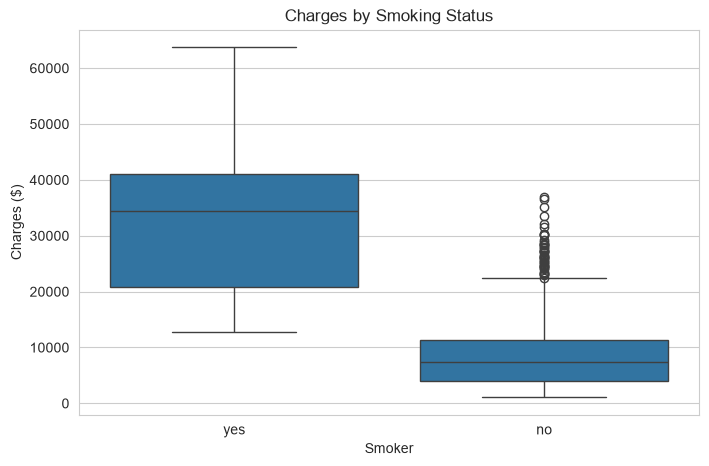

In [30]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.show()

## 8. Investigating Non-Smoker Outliers — BMI vs Charges

The boxplot revealed some non-smokers with unusually high charges. 
Hypothesis: high BMI (obesity) may explain these outliers even without smoking. 
Testing this using a scatter plot with BMI vs charges, colored by smoking status.

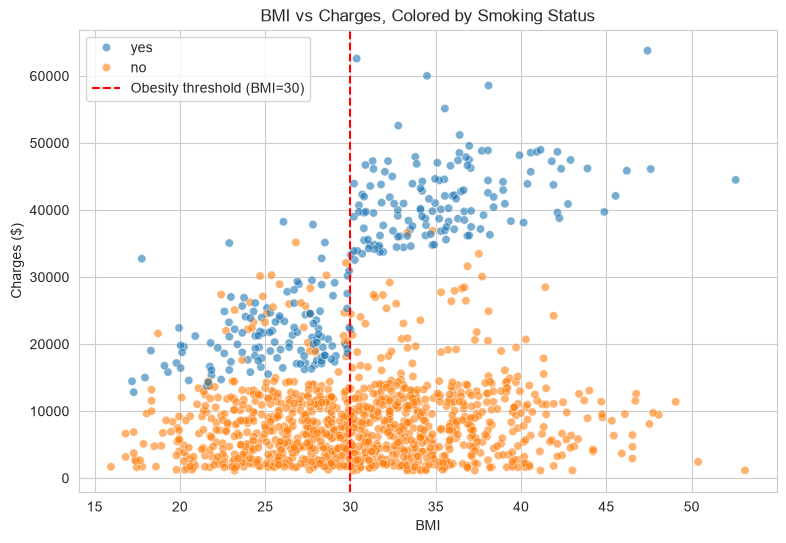

In [31]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('BMI vs Charges, Colored by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.axvline(x=30, color='red', linestyle='--', label='Obesity threshold (BMI=30)')
plt.legend()
plt.show()

## 9. Identifying Specific Outliers (Non-Smokers with High Charges)

Using the IQR method to mathematically identify which non-smoker records are outliers, 
then inspecting their characteristics (age, BMI) to understand the cause.

In [32]:
# Filter non-smokers only
non_smokers = df[df['smoker'] == 'no']

# Calculate IQR for charges within non-smokers
Q1 = non_smokers['charges'].quantile(0.25)
Q3 = non_smokers['charges'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Upper bound (outlier threshold): {upper_bound:.2f}")

# Find the actual outlier rows
outliers = non_smokers[non_smokers['charges'] > upper_bound]
print(f"\nNumber of outliers: {len(outliers)}")
outliers.sort_values('charges', ascending=False)

Q1: 3986.44
Q3: 11362.89
IQR: 7376.45
Upper bound (outlier threshold): 22427.56

Number of outliers: 46


,age,sex,bmi,children,smoker,region,charges
1206,59,female,34.800,2,no,southwest,36910.60803
1012,61,female,33.330,4,no,southeast,36580.28216
242,55,female,26.800,1,no,southwest,35160.13457
599,52,female,37.525,2,no,northwest,33471.97189
936,44,male,29.735,2,no,northeast,32108.66282
573,62,female,36.860,1,no,northeast,31620.00106
387,50,male,25.365,2,no,northwest,30284.64294
115,60,male,28.595,0,no,northeast,30259.99556
62,64,male,24.700,1,no,northwest,30166.61817
1258,55,male,37.715,3,no,northwest,30063.58055


## 10. Confirming the Pattern — Average Age & BMI of Outliers

Comparing the average age and BMI of outlier non-smokers against the overall non-smoker population 
to confirm whether these factors explain the high charges.

In [33]:
print("Outliers (high-charge non-smokers):")
print(f"Average Age: {outliers['age'].mean():.1f}")
print(f"Average BMI: {outliers['bmi'].mean():.1f}")

print("\nAll Non-Smokers:")
print(f"Average Age: {non_smokers['age'].mean():.1f}")
print(f"Average BMI: {non_smokers['bmi'].mean():.1f}")

Outliers (high-charge non-smokers):
Average Age: 46.3
Average BMI: 30.8

All Non-Smokers:
Average Age: 39.4
Average BMI: 30.7


**Finding**: Contrary to the initial hypothesis, BMI does not significantly differentiate outliers 
from the general non-smoker population (30.8 vs 30.7 — negligible difference). 
However, **age** shows a meaningful difference (46.3 vs 39.4), suggesting that age is the primary 
driver behind unusually high charges among non-smokers, not BMI.

## 11. Age vs Charges — Confirming the Age Pattern

Visualizing the relationship between age and charges, separated by smoking status, 
to confirm that age (not BMI) is driving the high charges seen among non-smoker outliers.

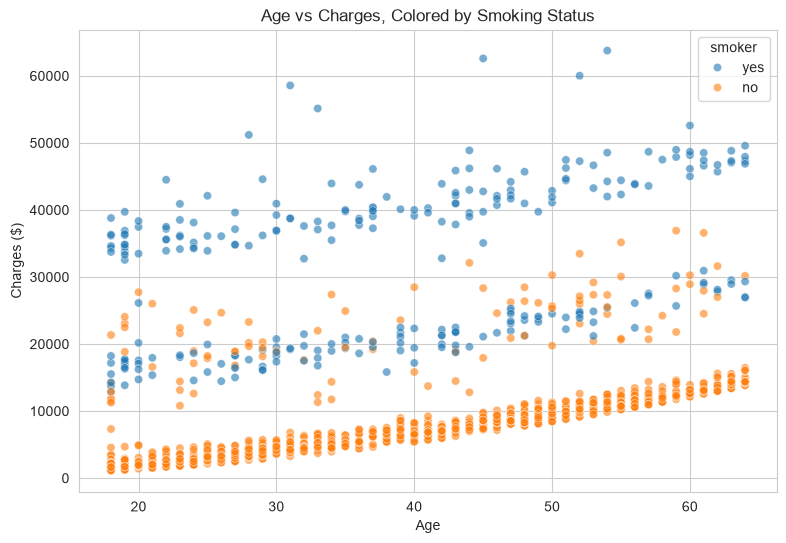

In [34]:
plt.figure(figsize=(9, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df, alpha=0.6)
plt.title('Age vs Charges, Colored by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.show()

## 12. Re-examining BMI — Checking Distribution, Not Just Average

The average BMI comparison showed no difference, but averages can hide patterns. 
Checking the BMI distribution (not just mean) among outliers to see if extreme values exist.

In [35]:
print("Outliers BMI distribution:")
print(outliers['bmi'].describe())

print("\nAll non-smokers BMI distribution:")
print(non_smokers['bmi'].describe())

Outliers BMI distribution:
count    46.000000
mean     30.823804
std       5.126124
min      22.420000
25%      26.500000
50%      30.732500
75%      35.182500
max      41.910000
Name: bmi, dtype: float64

All non-smokers BMI distribution:
count    1064.000000
mean       30.651795
std         6.043111
min        15.960000
25%        26.315000
50%        30.352500
75%        34.430000
max        53.130000
Name: bmi, dtype: float64


**Finding**: Re-examining the full BMI distribution (not just the mean) confirms that BMI does NOT 
differentiate outliers from the general non-smoker population — the max BMI among outliers (41.9) 
is actually lower than the overall non-smoker max (53.1), and all percentiles are nearly identical. 
This rules out BMI as a driver of these specific outliers; age remains the primary explanatory factor.

## 13. Correlation Analysis

Examining correlations between numeric features and charges to identify 
linear relationships that may inform feature selection.

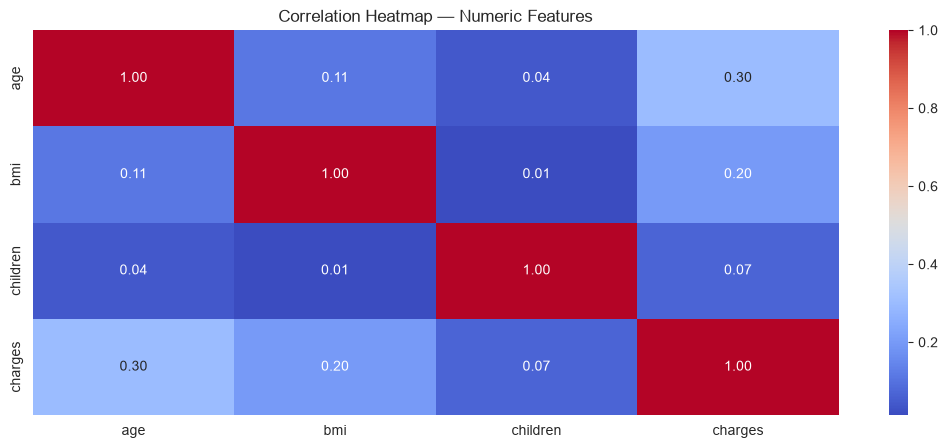

In [37]:
plt.figure(figsize=(13, 5))
numeric_df = df[['age', 'bmi', 'children', 'charges']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Numeric Features')
plt.show()

## 14. Categorical Variables — Sex and Region

Quick check on remaining categorical variables to see if they show any meaningful 
relationship with charges.

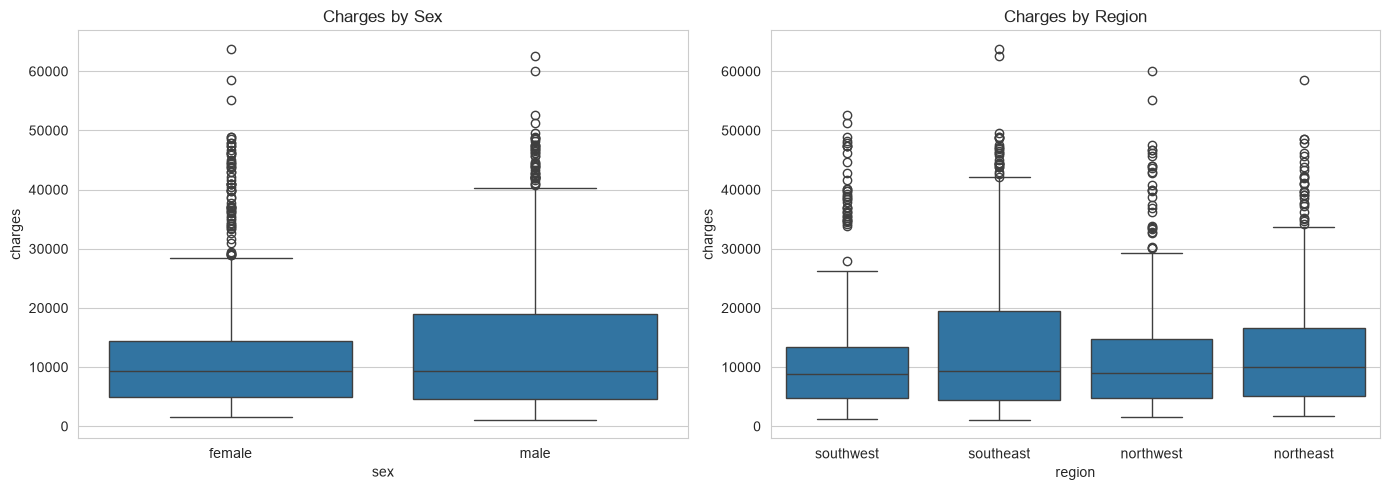

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='sex', y='charges', data=df, ax=axes[0])
axes[0].set_title('Charges by Sex')

sns.boxplot(x='region', y='charges', data=df, ax=axes[1])
axes[1].set_title('Charges by Region')

plt.tight_layout()
plt.show()

## 15. Key Findings Summary

1. **Smoking is the strongest predictor** of charges — smokers consistently have 
   significantly higher charges than non-smokers, regardless of age or BMI.

2. **Age has a moderate positive relationship** with charges (correlation: 0.30), 
   and holds true even within the non-smoker group — older non-smokers tend to 
   have higher charges than younger non-smokers.

3. **BMI shows a weak individual correlation** (0.20) with charges, but combined 
   with smoking status, high BMI amplifies charges dramatically — suggesting a 
   potential interaction effect between `smoker` and `bmi`.

4. **`children`, `sex`, and `region` show minimal to no relationship** with charges 
   and are likely weak predictors on their own.

5. **The target variable (`charges`) is right-skewed**, which will be considered 
   during model selection — a log transformation may improve model performance.

6. **Outliers were investigated and retained** — they represent valid, high-risk 
   customers (the exact group insurance pricing needs to predict accurately), 
   not data errors.

### Implications for Feature Engineering
- Consider creating a `smoker × bmi` interaction feature
- Consider log-transforming `charges` for training
- `sex` and `region` may have limited predictive value but will be retained 
  and encoded for the model to evaluate

## 16. Duplicate Records Check

Checking for and removing exact duplicate rows to avoid data leakage and biased model training.

**Finding**: 1 duplicate row found. Removing it since it adds no new information and could 
cause the model to overweight that particular data point.

In [40]:
# Check duplicates
print(f"Number of duplicate rows before: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()

# Confirm removal
print(f"Number of duplicate rows after: {df.duplicated().sum()}")
print(f"New dataset shape: {df.shape}")

Number of duplicate rows before: 1
Number of duplicate rows after: 0
New dataset shape: (1337, 7)


## 17. Distribution of Age, BMI, and Children

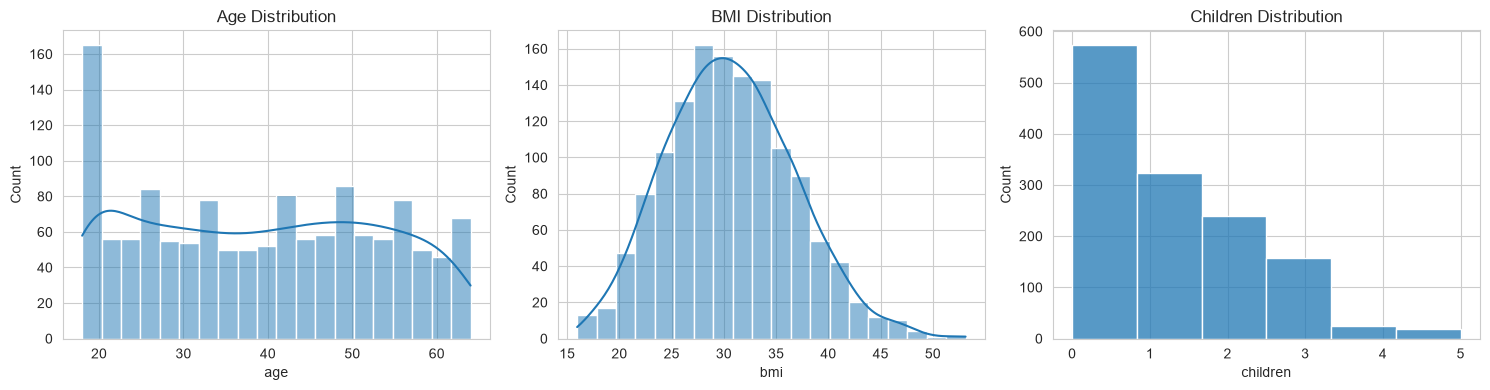

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution')
sns.histplot(df['bmi'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('BMI Distribution')
sns.histplot(df['children'], bins=6, kde=False, ax=axes[2])
axes[2].set_title('Children Distribution')
plt.tight_layout()
plt.show()

## 18. Categorical Variable Value Counts

In [43]:
for col in ['sex', 'smoker', 'region']:
    print(f"\n{col}:")
    print(df[col].value_counts())


sex:
sex
male      675
female    662
Name: count, dtype: int64

smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [7]:
import sys
sys.path.append('..')
import importlib
# importlib.reload(src.features.build_features)
from src.features.build_features import encode_categorical
from src.features.build_features import  encode_categorical

df_encoded = encode_categorical(df)
df_encoded.head(15)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0
5,31,1,25.740,0,0,3756.62160,0,1,0
6,46,1,33.440,1,0,8240.58960,0,1,0
7,37,1,27.740,3,0,7281.50560,1,0,0
8,37,0,29.830,2,0,6406.41070,0,0,0
9,60,1,25.840,0,0,28923.13692,1,0,0


In [8]:
# importlib.reload(src.features.build_features)
from src.features.build_features import encode_categorical, create_interaction_features

df_encoded = encode_categorical(df)
df_final = create_interaction_features(df_encoded)
df_final.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,smoker_bmi_interaction
0,19,1,27.900,0,1,16884.92400,0,0,1,27.9
1,18,0,33.770,1,0,1725.55230,0,1,0,0.0
2,28,0,33.000,3,0,4449.46200,0,1,0,0.0
3,33,0,22.705,0,0,21984.47061,1,0,0,0.0
4,32,0,28.880,0,0,3866.85520,1,0,0,0.0


In [9]:
# importlib.reload(src.features.build_features)
from src.features.build_features import build_features

df_ready = build_features(df)
df_ready.head()
print(f"\nFinal shape: {df_ready.shape}")
print(f"\nColumns: {df_ready.columns.tolist()}")


Final shape: (1338, 10)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest', 'smoker_bmi_interaction']


In [10]:
# importlib.reload(src.features.build_features)
from src.features.build_features import build_features, split_data

df_ready = build_features(df)
X_train, X_test, y_train, y_test = split_data(df_ready)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1070, 9)
Testing set: (268, 9)
